In [10]:
# =====================================================
# Section 1: Install & Import Libraries
# =====================================================

!pip install torch numpy pandas scipy tqdm scikit-learn

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split


In [11]:
# =====================================================
# Section 2: Create Travel Dataset
# =====================================================

users = [f"User_{i}" for i in range(1, 16)]  # 15 users
places = [
    "Bali", "Jakarta", "Yogyakarta", "Bandung", "Lombok",
    "Surabaya", "Medan", "Makassar", "Raja Ampat", "Komodo Island",
    "Sumatra", "Manado", "Semarang", "Aceh", "Padang"
]

data = []
for user in users:
    visited = random.sample(places, k=random.randint(4, 8))
    for place in visited:
        rating = random.randint(3, 5)
        data.append((user, place, rating))

df = pd.DataFrame(data, columns=["user_id", "item_id", "rating"])
print("✅ Sample Fake Data:")
print(df.head())


✅ Sample Fake Data:
  user_id        item_id  rating
0  User_1       Surabaya       4
1  User_1  Komodo Island       5
2  User_1         Lombok       3
3  User_1     Yogyakarta       3
4  User_1           Aceh       4


In [12]:
# =====================================================
# Section 3: Encode IDs & Split Data
# =====================================================

user2id = {u: i for i, u in enumerate(df["user_id"].unique())}
item2id = {i: j for j, i in enumerate(df["item_id"].unique())}
id2item = {v: k for k, v in item2id.items()}

df["user"] = df["user_id"].map(user2id)
df["item"] = df["item_id"].map(item2id)

train, test = train_test_split(df, test_size=0.2, random_state=42)

num_users = len(user2id)
num_items = len(item2id)

print(f"Users: {num_users}, Items: {num_items}")


Users: 15, Items: 15


In [13]:
# =====================================================
# Section 4: Build Adjacency Matrix for Graph
# =====================================================

def build_adj_matrix(df, num_users, num_items):
    edges = list(zip(df["user"], df["item"]))
    rows, cols = [], []
    for u, i in edges:
        rows.append(u)
        cols.append(num_users + i)
        rows.append(num_users + i)
        cols.append(u)
    values = np.ones(len(rows))
    adj = torch.sparse_coo_tensor(
        torch.LongTensor([rows, cols]),
        torch.FloatTensor(values),
        torch.Size([num_users + num_items, num_users + num_items])
    )
    return adj

adj = build_adj_matrix(train, num_users, num_items)
print("✅ Adjacency Matrix Built")


✅ Adjacency Matrix Built


In [14]:
# =====================================================
# Section 5: Define LightGCN Model
# =====================================================

class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32, num_layers=3):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.embedding_dim = embedding_dim
        self.num_layers = num_layers
        self.user_emb = nn.Embedding(num_users, embedding_dim)
        self.item_emb = nn.Embedding(num_items, embedding_dim)
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)

    def forward(self, adj):
        all_emb = torch.cat([self.user_emb.weight, self.item_emb.weight])
        embs = [all_emb]
        for _ in range(self.num_layers):
            all_emb = torch.sparse.mm(adj, all_emb)
            embs.append(all_emb)
        all_emb = torch.mean(torch.stack(embs, dim=1), dim=1)
        user_emb, item_emb = torch.split(all_emb, [self.num_users, self.num_items])
        return user_emb, item_emb

    def predict(self, user_emb, item_emb):
        return torch.matmul(user_emb, item_emb.t())


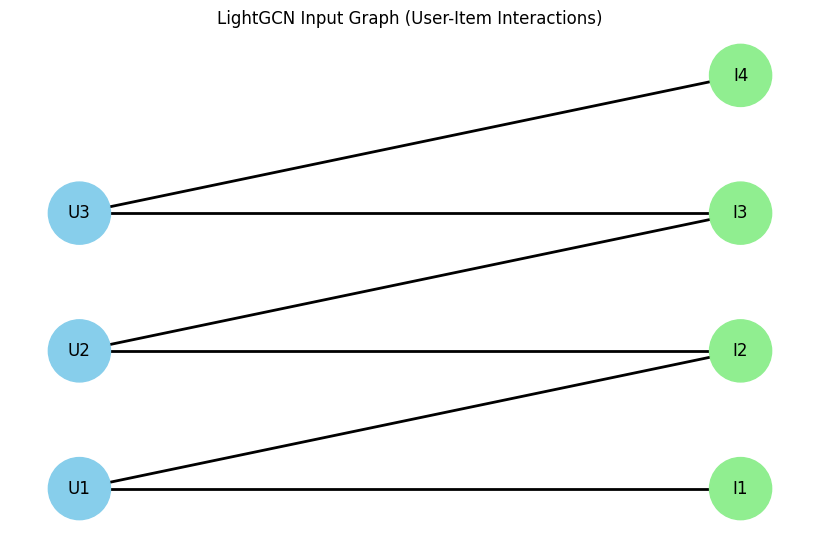

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a small  graph for visualization
G = nx.Graph()

# users and items
users = ['U1', 'U2', 'U3']
items = ['I1', 'I2', 'I3', 'I4']

# Add nodes with types
G.add_nodes_from(users, bipartite=0)
G.add_nodes_from(items, bipartite=1)

# Example edges (user-item interactions)
edges = [('U1', 'I1'), ('U1', 'I2'),
         ('U2', 'I2'), ('U2', 'I3'),
         ('U3', 'I3'), ('U3', 'I4')]
G.add_edges_from(edges)

# Positioning
pos = {}
pos.update((node, (0, i)) for i, node in enumerate(users))  # users on the left
pos.update((node, (1, i)) for i, node in enumerate(items))  # items on the right

# Draw base layer (input embeddings)
plt.figure(figsize=(8, 5))
nx.draw(G, pos, with_labels=True, node_color=["skyblue" if n in users else "lightgreen" for n in G.nodes()],
        node_size=2000, font_size=12, width=2)
plt.title("LightGCN Input Graph (User-Item Interactions)")
plt.show()


In [15]:
# =====================================================
# Section 6: Train LightGCN
# =====================================================

model = LightGCN(num_users, num_items, embedding_dim=32, num_layers=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
epochs = 80

for epoch in range(epochs):
    model.train()
    user_emb, item_emb = model(adj)
    users_batch = torch.LongTensor(train["user"].values)
    items_batch = torch.LongTensor(train["item"].values)
    scores = torch.sum(user_emb[users_batch] * item_emb[items_batch], dim=1)
    loss = -torch.mean(torch.log(torch.sigmoid(scores)))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")


Epoch 10/80 | Loss: -0.0000
Epoch 20/80 | Loss: -0.0000
Epoch 30/80 | Loss: -0.0000
Epoch 40/80 | Loss: -0.0000
Epoch 50/80 | Loss: -0.0000
Epoch 60/80 | Loss: -0.0000
Epoch 70/80 | Loss: -0.0000
Epoch 80/80 | Loss: -0.0000


In [ ]:
# =====================================================
# Section 7: Generate Recommendations
# =====================================================

model.eval()
with torch.no_grad():
    user_emb, item_emb = model(adj)
    scores = model.predict(user_emb, item_emb)

recommendations = {}
for u_name, u_idx in user2id.items():
    # Exclude items already interacted with
    seen = set(train[train["user"] == u_idx]["item"])
    user_scores = scores[u_idx].clone()
    user_scores[list(seen)] = -1e9
    top_items = torch.topk(user_scores, 3).indices.tolist()
    rec_places = [id2item[i] for i in top_items]
    recommendations[u_name] = rec_places

print("\n🎯 Top 3 Recommended Travel Destinations per User:\n")
for user, recs in recommendations.items():
    print(f"{user}: {', '.join(recs)}")



🎯 Top 3 Recommended Travel Destinations per User:

User_1: Bandung, Aceh, Manado
User_2: Bandung, Aceh, Manado
User_3: Bali, Aceh, Manado
User_4: Bandung, Makassar, Bali
User_5: Bandung, Bali, Aceh
User_6: Bandung, Sumatra, Yogyakarta
User_7: Manado, Bandung, Bali
User_8: Komodo Island, Bali, Aceh
User_9: Komodo Island, Makassar, Medan
User_10: Bandung, Bali, Sumatra
User_11: Makassar, Bali, Aceh
User_12: Komodo Island, Aceh, Makassar
User_13: Komodo Island, Bandung, Makassar
User_14: Aceh, Sumatra, Manado
User_15: Bali, Manado, Sumatra


In [17]:
# =====================================================
# Section 8: Evaluate Recommendation Quality
# =====================================================

def recall_at_k(preds, ground_truth, k):
    hits = len(set(preds[:k]) & set(ground_truth))
    return hits / len(ground_truth) if ground_truth else 0

def precision_at_k(preds, ground_truth, k):
    hits = len(set(preds[:k]) & set(ground_truth))
    return hits / k

def ndcg_at_k(preds, ground_truth, k):
    dcg, idcg = 0, 0
    for i, p in enumerate(preds[:k]):
        if p in ground_truth:
            dcg += 1 / np.log2(i + 2)
    for i in range(min(k, len(ground_truth))):
        idcg += 1 / np.log2(i + 2)
    return dcg / idcg if idcg > 0 else 0

# Evaluate on test data
K = 3
recalls, precisions, ndcgs = [], [], []

for user_name, u_idx in user2id.items():
    ground_truth = test[test["user"] == u_idx]["item"].tolist()
    preds = [item2id[p] for p in recommendations[user_name] if p in item2id]
    recalls.append(recall_at_k(preds, ground_truth, K))
    precisions.append(precision_at_k(preds, ground_truth, K))
    ndcgs.append(ndcg_at_k(preds, ground_truth, K))

print("\n📊 Evaluation Metrics:")
print(f"Recall@{K}:   {np.mean(recalls):.4f}")
print(f"Precision@{K}: {np.mean(precisions):.4f}")
print(f"NDCG@{K}:      {np.mean(ndcgs):.4f}")



📊 Evaluation Metrics:
Recall@3:   0.1889
Precision@3: 0.1333
NDCG@3:      0.1899
